# Appendix: Sensitivity Analysis
In this notebook, we aim to Figures S4-S8 for the various sensitivity plots within thr appendix of the "Covid Forecasting..." paper. 

## Load Dependencies

In [146]:
#%reset
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn import metrics

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

from sklearn.metrics import accuracy_score, confusion_matrix, matthews_corrcoef
from num2words import num2words
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, matthews_corrcoef, roc_auc_score, average_precision_score
import word2number
from word2number import w2n
from sklearn.tree import DecisionTreeClassifier
import pickle
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
import random
from matplotlib.patches import Polygon
import shap
import os

from Functions import prep_training_test_data_period, prep_training_test_data, calculate_metrics,cross_validation_leave_geo_out, prep_training_test_data_shifted, add_labels_to_subplots, LOOCV_by_HSA_dataset, save_in_HSA_dictionary, prepare_data_and_model
hfont = {'fontname':'Helvetica'}
palette = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#000000', '#e5c494']
import json 

## Load Data

In [147]:
HSA_weekly_data_all = pd.read_csv("HSA_Weekly_Surveillance.csv")

columns_to_remove = [col for col in HSA_weekly_data_all.columns if 'cases' in col]
HSA_weekly_data_no_cases_no_deaths = HSA_weekly_data_all.drop(columns=columns_to_remove)

columns_to_remove = [col for col in HSA_weekly_data_no_cases_no_deaths.columns if 'deaths' in col]
HSA_weekly_data_no_cases_no_deaths = HSA_weekly_data_no_cases_no_deaths.drop(columns=columns_to_remove)

HSA_weekly_data_all.loc[1, 'week_fifty-two_beds_over_15_100k']

0.0

## Define Global Variables

In [148]:
no_iterations = 100
geography_column = 'HSA_ID'
geo_split = 0.9
time_period = 'period'  # Choose 'period', 'exact', or 'shifted'
size_of_test_dataset = 1
train_weeks_for_initial_model = 1
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)

weeks_in_future = 3
weight_col = 'weight'
keep_output = True

## Location and County Data

In [114]:
## County Data 
data_by_county = pd.read_csv('county_time_data_all_dates.csv')

data_by_county = data_by_county.dropna(subset=['admits_weekly', 'deaths_weekly', 'cases_weekly', 'icu_weekly', 'beds_weekly', 'perc_covid'])
data_by_county['CTYNAME'] = data_by_county['CTYNAME'].apply(lambda x: x.split()[0])
data_by_county['CTYNAME'] = data_by_county['fips'].astype(str) + '' + data_by_county['CTYNAME']
data_by_county['beds_over_15_100k'] = (data_by_county['beds_weekly'] > 15) * 1

# Redo dates
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i

## DELTA POLYGON 
start_date = pd.to_datetime('2021-06-30')
end_date = pd.to_datetime('2021-10-26')
data_by_county['date'] = pd.to_datetime(data_by_county['date'])
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i
# Find the indices of rows that match the exact start and end dates
matching_indices_start = data_by_county.loc[data_by_county['date'] <= start_date].index.max()
matching_indices_end = data_by_county.loc[data_by_county['date'] <= end_date].index.max()
first_week_delta = data_by_county.loc[matching_indices_start, 'week']
last_week_delta = data_by_county.loc[matching_indices_end, 'week']
start_date = pd.to_datetime('2021-10-26')
end_date = pd.to_datetime('2022-09-27')
data_by_county['date'] = pd.to_datetime(data_by_county['date'])
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i
# Find the indices of rows that match the exact start and end dates
matching_indices_start = data_by_county.loc[data_by_county['date'] <= start_date].index.max()
matching_indices_end = data_by_county.loc[data_by_county['date'] <= end_date].index.max()
first_week_omricon = data_by_county.loc[matching_indices_start, 'week']
last_week_omricon = data_by_county.loc[matching_indices_end, 'week']

## CDC POLYGON 
start_date = pd.to_datetime('2021-03-01')
end_date = pd.to_datetime('2022-01-24')
data_by_county['date'] = pd.to_datetime(data_by_county['date'])
for i, week in enumerate(data_by_county['date'].unique()):
    data_by_county.loc[data_by_county['date'] == week, 'week'] = i
# Find the indices of rows that match the exact start and end dates
matching_indices_start = data_by_county.loc[data_by_county['date'] <= start_date].index.max()
matching_indices_end = data_by_county.loc[data_by_county['date'] <= end_date].index.max()
first_week_CDC = data_by_county.loc[matching_indices_start, 'week']
last_week_CDC = data_by_county.loc[matching_indices_end, 'week']

/var/folders/b1/ts1cmy7n6kg0gzvxmtp8cc_80000gn/T/ipykernel_10931/873074510.py:2: DtypeWarning: Columns (47,48,49,50,51,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  data_by_county = pd.read_csv('county_time_data_all_dates.csv')


## Adding Percent Exceeding Capacity

In [149]:
percent_exceed_capacity = []

# Iterate through the columns of the DataFrame
for column_name in HSA_weekly_data_all.columns:
    if 'beds_over_15_100k' in column_name:
        # Calculate the sum of the column and append it to the list
        column_sum = HSA_weekly_data_all[column_name].sum() / len(HSA_weekly_data_all[column_name])
        percent_exceed_capacity.append(column_sum)

## Define Hyperparameter Tuning Function

In [150]:
def hyperparameter_train_model_DT(X_train, y_train, sample_weights, decision_tree):   
    # Here are the hyperparamters
    param_grid = {
    'max_depth': [5, 8, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 3],
}
    
    # Now we construct the grid of hyperparamters to train
    grid_search = GridSearchCV(estimator=decision_tree,
                           param_grid=param_grid,
                           scoring='average_precision',  # Optimize for F1-score
                           cv=5,
                           n_jobs=-1, # This utilizes all cores in the CPU
                           verbose=1) 
    # Now evaluate
    grid_search.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Now we return the best model for usage
    best_model = grid_search.best_estimator_
    
    return best_model

## Preparing Training Function

In [151]:
def prep_training_test_data(
    data, no_weeks, weeks_in_future, geography, weight_col, keep_output
):
    ## Get the weeks for the x and y datasets
    x_weeks = []
    y_weeks = []
    for week in no_weeks:
        test_week = int(week) + weeks_in_future
        x_weeks.append("_" + num2words(week) + "_")
        y_weeks.append("_" + num2words(test_week) + "_")
    X_data = pd.DataFrame()
    y_data = pd.DataFrame()
    weights_all = pd.DataFrame()
    missing_data = []
    ## Now get the training data
    k = 0
    for x_week in x_weeks:
        y_week = y_weeks[k]
        k += 1
        weeks_x = [col for col in data.columns if x_week in col]
        columns_x = [geography] + weeks_x + [weight_col]
        data_x = data[columns_x]
        weeks_y = [col for col in data.columns if y_week in col]
        columns_y = [geography] + weeks_y
        data_y = data[columns_y]
        # ensure they have the same amount of data
        # remove rows in test_data1 with NA in test_data2
        data_x = data_x.dropna()
        data_x = data_x[data_x[geography].isin(data_y[geography])]
        # remove rows in test_data2 with NA in test_data1
        data_y = data_y.dropna()
        data_y = data_y[data_y[geography].isin(data_x[geography])]
        data_x = data_x[data_x[geography].isin(data_y[geography])]
        data_x_no_HSA = len(data_x[geography].unique())
        missing_data.append(
            (
                (len(data[geography].unique()) - data_x_no_HSA)
                / len(data[geography].unique())
            )
            * 100
        )
        # get weights
        # weights = weight_data[weight_data[geography].isin(data_x[geography])][[geography, weight_col]]
        X_week = data_x.iloc[:, 1 : len(columns_x)]  # take away y, leave weights for mo
        y_week = data_y.iloc[:, -1]
        y_week = y_week.astype(int)
        weights = X_week.iloc[:, -1]
        if keep_output:
            X_week = X_week.iloc[
                :, : len(X_week.columns) - 1
            ]  # remove the weights and leave "target" for that week
            # rename columns for concatenation
            X_week.columns = range(1, len(data_x.columns) - 1)
        else:
            X_week = X_week.iloc[
                :, : len(X_week.columns) - 2
            ]  # remove the weights and  "target" for that week
            X_week.columns = range(
                1, len(data_x.columns) - 2
            )  # remove the weights and  "target" for that week
            # rename columns for concatenation
        y_week.rename("0", inplace=True)
        X_data = pd.concat([X_data, X_week], axis = 0)
        y_data = pd.concat([y_data, y_week], axis = 0)
        weights.rename("0", inplace=True)
        weights_all = pd.concat([weights_all, weights], axis = 0)
    X_data.reset_index(drop=True, inplace=True)
    y_data.reset_index(drop=True, inplace=True)
    weights_all.reset_index(drop=True, inplace=True)
    return (X_data, y_data, weights_all, missing_data)

## Preparing Folder for the Results

In [152]:
# Preparing folders for the different models
dt_folder = "decisionTreeStatsAppendix"

# Double check in-case folders are not prepared
def create_directory_if_not_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Created directory: {directory_path}")
    else:
        print(f"Directory already exists: {directory_path}")

# Now apply to the folder names
create_directory_if_not_exists(dt_folder)

Directory already exists: decisionTreeStatsAppendix


## Prepare Data (Naive/Full/Reduced/CDC A/ CDC B)

In [187]:
# Naive 
columns_to_select = HSA_weekly_data_all.filter(regex="HSA|beds_over_15_100k|weight").columns.tolist()
naive = HSA_weekly_data_all[columns_to_select]

# Reduced 
reduced_regex_pattern = (
    "HSA|weight|beds_over_15_100k|"
    "admits|icu|beds|perc_covid"
)

columns_to_select_reduced = HSA_weekly_data_all.filter(
    regex=reduced_regex_pattern
).columns.tolist()

columns_to_select_reduced = [col for col in columns_to_select_reduced if "cases" not in col and "deaths" not in col] # Making sure we do not have the cases

reduced = HSA_weekly_data_all[columns_to_select_reduced]

# CDC Optimized
cdc_optimized_pattern = ("HSA|weight|cases|admits|perc_covid|beds_over")
columns_to_select_cdc = HSA_weekly_data_all.filter(
    regex=cdc_optimized_pattern
).columns.tolist()
columns_to_select_cdc = [col for col in columns_to_select_cdc if "delta" not in col]
cdc = HSA_weekly_data_all[columns_to_select_cdc]

# Full
full_regex_pattern = (
    "HSA|weight|beds_over_15_100k|"
    "cases|deaths|admits|icu|beds|perc_covid"
)

columns_to_select_full = HSA_weekly_data_all.filter(
    regex=full_regex_pattern
).columns.tolist()

full = HSA_weekly_data_all[columns_to_select_full]

subsets_HSA = [full, reduced, naive, cdc]

# S7 - Changing size of the training set
We will be utilizing only the past 4/10/26 weeks for analysis

In [190]:
no_iterations = 100
geography_column = 'HSA_ID'
geo_split = 0.9
time_period = 'period'  # Choose 'period', 'exact', or 'shifted'
size_of_test_dataset = 1
train_weeks_for_initial_model = 4
weeks_to_predict = range(4, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)

weeks_in_future = 3
weight_col = 'weight'
keep_output = True

# new parameters
ROLLING_TRAINING_WINDOW_SIZE = 4
first_target_week = ROLLING_TRAINING_WINDOW_SIZE + weeks_in_future
max_data_week_available = 122
last_target_week = max_data_week_available
weeks_to_predict = range(first_target_week, last_target_week + 1)


size_of_test_dataset = 1
names = ["Full", "Reduced", "Naive", "CDC"]
count = 0
for subsets in subsets_HSA: # Cycle through the different datasets
    # Make sure these are entirely reset before each cycle
    ROC_by_week_dt_period = []
    PRC_by_week_dt_period = [] # This is for the PRC graph
    sensitivity_by_week_dt_period = []
    specificity_by_week_dt_period = []
    ppv_by_week_dt_period = []
    npv_by_week_dt_period = []
    accuracy_by_week_dt_period = []
    norm_MCC_by_week_dt_period = []
    for prediction_week in weeks_to_predict:
        end_train_features_week_inclusive = prediction_week - weeks_in_future 
        start_train_features_week_inclusive = end_train_features_week_inclusive - ROLLING_TRAINING_WINDOW_SIZE + 1
        
        training_no_weeks_for_X_features = range(start_train_features_week_inclusive, end_train_features_week_inclusive + 1)
        print(f"  Training X (features) from weeks: {list(training_no_weeks_for_X_features)}")
        
        test_features_week_for_X = prediction_week - weeks_in_future # 

        test_no_weeks_for_X_features = range(test_features_week_for_X, test_features_week_for_X + size_of_test_dataset)
        print(f"  Test X (features) from weeks: {list(test_no_weeks_for_X_features)}")
        print(f"  Actual Target Y week: {prediction_week}") 
    
        X_train_dt, y_train_dt, weights_dt, missing_data_train_HSA = prep_training_test_data(subsets, no_weeks=training_no_weeks_for_X_features, weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
    
        X_test_dt, y_test_dt, weights_test_dt, missing_data_test_HSA = prep_training_test_data(subsets, no_weeks=test_no_weeks_for_X_features, weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
        
        weights_dt = weights_dt.to_numpy()
        weights_dt = weights_dt.ravel()
        
        # Instantiate classifier
        clf_dt =  DecisionTreeClassifier(random_state=10, class_weight='balanced') # 
        
        # Hyperparamter train
        best_clf_dt = hyperparameter_train_model_DT(X_train_dt, y_train_dt, weights_dt, clf_dt)        
        
        # Make predictions on the test set
        y_pred = best_clf_dt.predict(X_test_dt)
        y_pred_proba = best_clf_dt.predict_proba(X_test_dt)
    
        # Evaluate the accuracy of the model
        accuracy_by_week_dt_period.append(accuracy_score(y_test_dt, y_pred))
        if len(np.unique(y_test_dt)) > 1:
        # Calculate ROC AUC score only if there are multiple classes
            ROC_by_week_dt_period.append(roc_auc_score(y_test_dt, y_pred_proba[:, 1]))
            PRC_by_week_dt_period.append(average_precision_score(y_test_dt, y_pred_proba[:, 1]))
        else:
            ROC_by_week_dt_period.append(np.nan)
            PRC_by_week_dt_period.append(np.nan)
        conf_matrix = confusion_matrix(y_test_dt, y_pred)
    
        sensitivity, specificity, ppv, npv = calculate_metrics(conf_matrix)
        sensitivity_by_week_dt_period.append(sensitivity)
        specificity_by_week_dt_period.append(specificity)
    
        ppv_by_week_dt_period.append(ppv)
        npv_by_week_dt_period.append(npv)
    
        norm_MCC_by_week_dt_period.append((matthews_corrcoef(y_test_dt, y_pred) + 1)/2)
        
    # Organize the file names - change to represent the proper dataset
    dt_performance_name = os.path.join(dt_folder, f"{names[count]}_performance_S7_4.pkl")
    
    # Organize into a dictionary
    dt_performance_stats = {
        "ROC": ROC_by_week_dt_period,
        "PRC": PRC_by_week_dt_period,
        "accuracy": accuracy_by_week_dt_period,
        "sensitivity": sensitivity_by_week_dt_period,
        "specificity": specificity_by_week_dt_period,
        "ppv": ppv_by_week_dt_period,
        "npv": npv_by_week_dt_period,
        "MCC": norm_MCC_by_week_dt_period
    }
    
    # Open
    with open(dt_performance_name, 'wb') as f:
        pickle.dump(dt_performance_stats, f)
    
    count += 1

  Training X (features) from weeks: [1, 2, 3, 4]
  Test X (features) from weeks: [4]
  Actual Target Y week: 7
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Training X (features) from weeks: [2, 3, 4, 5]
  Test X (features) from weeks: [5]
  Actual Target Y week: 8
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Training X (features) from weeks: [3, 4, 5, 6]
  Test X (features) from weeks: [6]
  Actual Target Y week: 9
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Training X (features) from weeks: [4, 5, 6, 7]
  Test X (features) from weeks: [7]
  Actual Target Y week: 10
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Training X (features) from weeks: [5, 6, 7, 8]
  Test X (features) from weeks: [8]
  Actual Target Y week: 11
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Training X (features) from weeks: [6, 7, 8, 9]
  Test X (features) from weeks: [9]
  Actual Target Y week: 12
Fitting 5 folds for each o

# S6 - Update how far in advance 

In [177]:
no_iterations = 100
geography_column = 'HSA_ID'
geo_split = 0.9
time_period = 'period'  # Choose 'period', 'exact', or 'shifted'
size_of_test_dataset = 1
train_weeks_for_initial_model = 1
weeks_in_future = 4

weeks_to_predict = range(1, 123 - size_of_test_dataset - weeks_in_future - train_weeks_for_initial_model)
weight_col = 'weight'
keep_output = True

size_of_test_dataset = 1
names = ["Full", "Reduced", "Naive", "CDC"]
count = 0
for subsets in subsets_HSA: # Cycle through the different datasets
    # Make sure these are entirely reset before each cycle
    ROC_by_week_dt_period = []
    PRC_by_week_dt_period = [] # This is for the PRC graph
    sensitivity_by_week_dt_period = []
    specificity_by_week_dt_period = []
    ppv_by_week_dt_period = []
    npv_by_week_dt_period = []
    accuracy_by_week_dt_period = []
    norm_MCC_by_week_dt_period = []
    for prediction_week in weeks_to_predict:
        print(prediction_week)
        print(range(1 , int(prediction_week + train_weeks_for_initial_model) + 1))
        print(range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1))
  
    
        X_train_dt, y_train_dt, weights_dt, missing_data_train_HSA = prep_training_test_data(subsets, no_weeks=range(1, int(prediction_week + train_weeks_for_initial_model) + 1), weeks_in_future=weeks_in_future, geography='HSA_ID', weight_col='weight', keep_output=True)
    
        X_test_dt, y_test_dt, weights_test_dt, missing_data_test_HSA = prep_training_test_data(subsets, no_weeks=range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1), weeks_in_future=weeks_in_future, geography='HSA_ID', weight_col='weight', keep_output=True)
        
        weights_dt = weights_dt.to_numpy()
        weights_dt = weights_dt.ravel()
        
        # Instantiate classifier
        clf_dt =  DecisionTreeClassifier(random_state=10, class_weight='balanced') # 
        
        best_clf_dt = hyperparameter_train_model_DT(X_train_dt, y_train_dt, weights_dt, clf_dt)        
        
        y_pred = best_clf_dt.predict(X_test_dt)
        y_pred_proba = best_clf_dt.predict_proba(X_test_dt)
    
        # Evaluate the accuracy of the model
        accuracy_by_week_dt_period.append(accuracy_score(y_test_dt, y_pred))
        if len(np.unique(y_test_dt)) > 1:
        # Calculate ROC AUC score only if there are multiple classes
            ROC_by_week_dt_period.append(roc_auc_score(y_test_dt, y_pred_proba[:, 1]))
            PRC_by_week_dt_period.append(average_precision_score(y_test_dt, y_pred_proba[:, 1]))
        else:
            ROC_by_week_dt_period.append(np.nan)
            PRC_by_week_dt_period.append(np.nan)
        conf_matrix = confusion_matrix(y_test_dt, y_pred)
    
        sensitivity, specificity, ppv, npv = calculate_metrics(conf_matrix)
        sensitivity_by_week_dt_period.append(sensitivity)
        specificity_by_week_dt_period.append(specificity)
    
        ppv_by_week_dt_period.append(ppv)
        npv_by_week_dt_period.append(npv)
    
        norm_MCC_by_week_dt_period.append((matthews_corrcoef(y_test_dt, y_pred) + 1)/2)
        
    # Organize the file names - change to represent the proper dataset
    dt_performance_name = os.path.join(dt_folder, f"{names[count]}_performance_S6_4.pkl")
    
    # Organize into a dictionary
    dt_performance_stats = {
        "ROC": ROC_by_week_dt_period,
        "PRC": PRC_by_week_dt_period,
        "accuracy": accuracy_by_week_dt_period,
        "sensitivity": sensitivity_by_week_dt_period,
        "specificity": specificity_by_week_dt_period,
        "ppv": ppv_by_week_dt_period,
        "npv": npv_by_week_dt_period,
        "MCC": norm_MCC_by_week_dt_period
    }
    
    # Open
    with open(dt_performance_name, 'wb') as f:
        pickle.dump(dt_performance_stats, f)
    
    count += 1

1
range(1, 3)
range(3, 4)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
2
range(1, 4)
range(4, 5)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
3
range(1, 5)
range(5, 6)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
4
range(1, 6)
range(6, 7)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
5
range(1, 7)
range(7, 8)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
6
range(1, 8)
range(8, 9)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
7
range(1, 9)
range(9, 10)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
8
range(1, 10)
range(10, 11)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
9
range(1, 11)
range(11, 12)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
10
range(1, 12)
range(12, 13)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
11
range(1, 13)
range(13, 14)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
12
range(1, 14)
range(14, 15

# S4 - Shifted Analysis

In [142]:
no_iterations = 100
geography_column = 'HSA_ID'
geo_split = 0.9
time_period = 'shifted'  
size_of_test_dataset = 1
train_weeks_for_initial_model = 1
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)

weeks_in_future = 3
weight_col = 'weight'
keep_output = True

size_of_test_dataset = 1
names = ["CDC"]
count = 0
for subsets in subsets_HSA: # Cycle through the different datasets
    # Make sure these are entirely reset before each cycle
    ROC_by_week_dt_period = []
    PRC_by_week_dt_period = [] 
    sensitivity_by_week_dt_period = []
    specificity_by_week_dt_period = []
    ppv_by_week_dt_period = []
    npv_by_week_dt_period = []
    accuracy_by_week_dt_period = []
    norm_MCC_by_week_dt_period = []
    for prediction_week in weeks_to_predict:
        print(prediction_week)
        print(range(1 , int(prediction_week + train_weeks_for_initial_model) + 1))
        print(range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1))
  
    
        X_train_dt, y_train_dt, weights_dt, missing_data_train_HSA = prep_training_test_data_shifted(subsets, no_weeks=range(1, int(prediction_week + train_weeks_for_initial_model) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
    
        X_test_dt, y_test_dt, weights_test_dt, missing_data_test_HSA = prep_training_test_data_shifted(subsets, no_weeks=range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
        
        weights_dt = weights_dt.to_numpy()
        weights_dt = weights_dt.ravel()
        
        # Instantiate classifier
        clf_dt =  DecisionTreeClassifier(random_state=10, class_weight='balanced') # 
        
        # Hyperparamter train
        best_clf_dt = hyperparameter_train_model_DT(X_train_dt, y_train_dt, weights_dt, clf_dt)        
        
        # Make predictions on the test set
        y_pred = best_clf_dt.predict(X_test_dt)
        y_pred_proba = best_clf_dt.predict_proba(X_test_dt)
    
        # Evaluate the accuracy of the model
        accuracy_by_week_dt_period.append(accuracy_score(y_test_dt, y_pred))
        if len(np.unique(y_test_dt)) > 1:
        # Calculate ROC AUC score only if there are multiple classes
            ROC_by_week_dt_period.append(roc_auc_score(y_test_dt, y_pred_proba[:, 1]))
            PRC_by_week_dt_period.append(average_precision_score(y_test_dt, y_pred_proba[:, 1]))
        else:
            ROC_by_week_dt_period.append(np.nan)
            PRC_by_week_dt_period.append(np.nan)
        conf_matrix = confusion_matrix(y_test_dt, y_pred)
    
        sensitivity, specificity, ppv, npv = calculate_metrics(conf_matrix)
        sensitivity_by_week_dt_period.append(sensitivity)
        specificity_by_week_dt_period.append(specificity)
    
        ppv_by_week_dt_period.append(ppv)
        npv_by_week_dt_period.append(npv)
    
        norm_MCC_by_week_dt_period.append((matthews_corrcoef(y_test_dt, y_pred) + 1)/2)
        
    # Organize the file names - change to represent the proper dataset
    dt_performance_name = os.path.join(dt_folder, f"{names[count]}_performance_S4_shifted.pkl")
    
    # Organize into a dictionary
    dt_performance_stats = {
        "ROC": ROC_by_week_dt_period,
        "PRC": PRC_by_week_dt_period,
        "accuracy": accuracy_by_week_dt_period,
        "sensitivity": sensitivity_by_week_dt_period,
        "specificity": specificity_by_week_dt_period,
        "ppv": ppv_by_week_dt_period,
        "npv": npv_by_week_dt_period,
        "MCC": norm_MCC_by_week_dt_period
    }
    
    # Open
    with open(dt_performance_name, 'wb') as f:
        pickle.dump(dt_performance_stats, f)
    
    count += 1

1
range(1, 3)
range(3, 4)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
2
range(1, 4)
range(4, 5)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
3
range(1, 5)
range(5, 6)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
4
range(1, 6)
range(6, 7)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
5
range(1, 7)
range(7, 8)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
6
range(1, 8)
range(8, 9)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
7
range(1, 9)
range(9, 10)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
8
range(1, 10)
range(10, 11)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
9
range(1, 11)
range(11, 12)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
10
range(1, 12)
range(12, 13)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
11
range(1, 13)
range(13, 14)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
12
range(1, 14)
r


# S8 - Update every 4 iterations

In [159]:
no_iterations = 100
geography_column = 'HSA_ID'
geo_split = 0.9
time_period = 'exact'
size_of_test_dataset = 1
train_weeks_for_initial_model = 1
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)

weeks_in_future = 3
weight_col = 'weight'
keep_output = True

size_of_test_dataset = 1
names = ["CDC"]
count = 0
for subsets in subsets_HSA: # Cycle through the different datasets
    # Make sure these are entirely reset before each cycle
    ROC_by_week_dt_period = []
    PRC_by_week_dt_period = [] # This is for the PRC graph
    sensitivity_by_week_dt_period = []
    specificity_by_week_dt_period = []
    ppv_by_week_dt_period = []
    npv_by_week_dt_period = []
    accuracy_by_week_dt_period = []
    norm_MCC_by_week_dt_period = []
    
    # New parameters 
    best_clf_dt = None  
    retrain_counter = 0
    
    for prediction_week in weeks_to_predict:
        print(prediction_week)
        print(range(1 , int(prediction_week + train_weeks_for_initial_model) + 1))
        print(range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1))
    
        X_train_dt, y_train_dt, weights_dt, missing_data_train_HSA = prep_training_test_data(subsets, no_weeks=range(1, int(prediction_week + train_weeks_for_initial_model) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
    
        X_test_dt, y_test_dt, weights_test_dt, missing_data_test_HSA = prep_training_test_data(subsets, no_weeks=range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
        
        weights_dt = weights_dt.to_numpy()
        weights_dt = weights_dt.ravel()
        
        if retrain_counter % 4 == 0:    
            # Instantiate classifier
            clf_dt =  DecisionTreeClassifier(random_state=10, class_weight='balanced') # 
            
            # Hyperparamter train
            best_clf_dt = hyperparameter_train_model_DT(X_train_dt, y_train_dt, weights_dt, clf_dt)        
        
        # Make predictions on the test set
        y_pred = best_clf_dt.predict(X_test_dt)
        y_pred_proba = best_clf_dt.predict_proba(X_test_dt)
    
        # Evaluate the accuracy of the model
        accuracy_by_week_dt_period.append(accuracy_score(y_test_dt, y_pred))
        if len(np.unique(y_test_dt)) > 1:
        # Calculate ROC AUC score only if there are multiple classes
            ROC_by_week_dt_period.append(roc_auc_score(y_test_dt, y_pred_proba[:, 1]))
            PRC_by_week_dt_period.append(average_precision_score(y_test_dt, y_pred_proba[:, 1]))
        else:
            ROC_by_week_dt_period.append(np.nan)
            PRC_by_week_dt_period.append(np.nan)
        conf_matrix = confusion_matrix(y_test_dt, y_pred)
    
        sensitivity, specificity, ppv, npv = calculate_metrics(conf_matrix)
        sensitivity_by_week_dt_period.append(sensitivity)
        specificity_by_week_dt_period.append(specificity)
    
        ppv_by_week_dt_period.append(ppv)
        npv_by_week_dt_period.append(npv)
    
        norm_MCC_by_week_dt_period.append((matthews_corrcoef(y_test_dt, y_pred) + 1)/2)
        
        retrain_counter += 1
        
    # Organize the file names - change to represent the proper dataset
    dt_performance_name = os.path.join(dt_folder, f"{names[count]}_performance_S8.pkl")
    
    # Organize into a dictionary
    dt_performance_stats = {
        "ROC": ROC_by_week_dt_period,
        "PRC": PRC_by_week_dt_period,
        "accuracy": accuracy_by_week_dt_period,
        "sensitivity": sensitivity_by_week_dt_period,
        "specificity": specificity_by_week_dt_period,
        "ppv": ppv_by_week_dt_period,
        "npv": npv_by_week_dt_period,
        "MCC": norm_MCC_by_week_dt_period
    }
    
    # Open
    with open(dt_performance_name, 'wb') as f:
        pickle.dump(dt_performance_stats, f)
    
    count += 1

1
range(1, 3)
range(3, 4)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
2
range(1, 4)
range(4, 5)
3
range(1, 5)
range(5, 6)
4
range(1, 6)
range(6, 7)
5
range(1, 7)
range(7, 8)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
6
range(1, 8)
range(8, 9)
7
range(1, 9)
range(9, 10)
8
range(1, 10)
range(10, 11)
9
range(1, 11)
range(11, 12)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
10
range(1, 12)
range(12, 13)
11
range(1, 13)
range(13, 14)
12
range(1, 14)
range(14, 15)
13
range(1, 15)
range(15, 16)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
14
range(1, 16)
range(16, 17)
15
range(1, 17)
range(17, 18)
16
range(1, 18)
range(18, 19)
17
range(1, 19)
range(19, 20)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
18
range(1, 20)
range(20, 21)
19
range(1, 21)
range(21, 22)
20
range(1, 22)
range(22, 23)
21
range(1, 23)
range(23, 24)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
22
range(1, 24)
range(24, 25)
23


# S5 - Changing to 10/20 per 100,000

In [23]:
import re
filtered_complete = HSA_weekly_data_all
include_equal = True
inplace=True
thresholds = (10, 20)

cmp = (lambda s, t: s >= t) if include_equal else (lambda s, t: s > t)
out = filtered_complete if inplace else filtered_complete.copy()

out.columns = out.columns.str.strip()

pat = re.compile(r'^week_([a-z\s-]+)_beds$')
bed_cols = [c for c in out.columns if pat.match(c)]

for col in bed_cols:
    week_words = pat.match(col).group(1)  
    s = pd.to_numeric(out[col], errors='coerce')

    for t in thresholds:
        new_col = f'week_{week_words}_beds_over_{t}_100k'
        mask = cmp(s, t)
        flag = pd.Series(mask, index=out.index, dtype='boolean')
        flag[s.isna()] = pd.NA
        out[new_col] = flag.astype('Int64')  # 1/0/<NA>
filtered_complete = out

In [51]:
import pandas as pd
import pandas as pd
import re

def update_beds_and_icu_10(df, beds_threshold=10):
    df = df.copy()
    beds_cols = [c for c in df.columns if re.fullmatch(r"week_[a-zA-Z0-9_]+_beds", c)]
    icu_cols  = [c for c in df.columns if re.fullmatch(r"week_[a-zA-Z0-9_]+_icu", c)]
    delta_cols = [c for c in df.columns if re.fullmatch(r".*delta_(beds|icu)", c)]
    
    df[beds_cols] = df[beds_cols] / 7
    df[icu_cols] = df[icu_cols] / 7
    df[delta_cols] = df[delta_cols] / 7

    over_cols = [c for c in df.columns if re.fullmatch(r"week_[a-zA-Z0-9_]+_beds_over_10_100k", c)]
    
    for col in over_cols:
        beds_col = re.sub(r"_beds_over_10_100k$", "_beds", col)
        if beds_col in df.columns:
            df[col] = (df[beds_col] > beds_threshold).astype(int)
    
    return df

def update_beds_and_icu_20(df, beds_threshold=10):
    df = df.copy()
    
    beds_cols = [c for c in df.columns if re.fullmatch(r"week_[a-zA-Z0-9_]+_beds", c)]
    icu_cols  = [c for c in df.columns if re.fullmatch(r"week_[a-zA-Z0-9_]+_icu", c)]
    delta_cols = [c for c in df.columns if re.fullmatch(r".*delta_(beds|icu)", c)]
    
    df[beds_cols] = df[beds_cols] / 7
    df[icu_cols] = df[icu_cols] / 7
    df[delta_cols] = df[delta_cols] / 7

    over_cols = [c for c in df.columns if re.fullmatch(r"week_[a-zA-Z0-9_]+_beds_over_20_100k", c)]
    
    for col in over_cols:
        beds_col = re.sub(r"_beds_over_20_100k$", "_beds", col)
        if beds_col in df.columns:
            df[col] = (df[beds_col] > beds_threshold).astype(int)
    
    return df

In [71]:
# First we read in the data
HSA_weekly_data_all_10 = pd.read_csv("hsa_time_data_all_dates_weekly_10_per_100.csv")
HSA_weekly_data_all_20 = pd.read_csv("hsa_time_data_all_dates_weekly_20_per_100.csv")

In [70]:
HSA_weekly_data_all_20

,Unnamed: 0,HSA_ID,week_one_cases,week_one_deaths,week_one_admits,week_one_icu,week_one_beds,week_one_perc_covid,week_one_cases_delta,week_one_deaths_delta,...,week_one hundred and twenty-two_beds,week_one hundred and twenty-two_perc_covid,week_one hundred and twenty-two_cases_delta,week_one hundred and twenty-two_deaths_delta,week_one hundred and twenty-two_admits_delta,week_one hundred and twenty-two_icu_delta,week_one hundred and twenty-two_beds_delta,week_one hundred and twenty-two_perc_covid_delta,week_one hundred and twenty-two_beds_over_20_100k,weight
0,0,1,26.0,0.600098,1.318896,0.006729,0.471034,0.002834,NaN,NaN,...,14.507854,0.012571,-24.0,-0.046161,-4.616135,0.000000,-15.826750,-0.013714,0.0,0.000458
1,1,2,50.0,1.138492,0.903565,0.000000,0.000000,0.000000,NaN,NaN,...,14.908819,0.013859,3.0,0.015812,-0.903565,-0.354972,-15.586493,-0.015629,0.0,0.001336
2,2,3,59.0,2.077075,0.670565,0.005132,0.670565,0.003202,NaN,NaN,...,20.284588,0.014157,-11.0,0.000000,-4.861595,-0.802283,-29.672496,-0.020709,1.0,0.001800
3,3,4,15.0,1.660595,0.345059,0.000880,0.258794,0.001074,NaN,NaN,...,10.696820,0.006715,-38.0,0.169079,-10.136100,-1.078308,-71.772213,-0.044294,0.0,0.003498
4,4,5,114.0,0.197389,2.631851,0.065221,1.369637,0.008810,NaN,NaN,...,6.579628,0.009452,-8.0,0.013159,-1.315926,-0.684818,-29.326340,-0.018247,0.0,0.001605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,799,904,49.0,0.000000,0.939351,0.017253,0.684384,0.002749,NaN,NaN,...,3.788716,0.002236,-20.0,0.000000,-2.379689,-0.192343,-17.409307,-0.009714,0.0,0.003446
800,800,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.310873,0.006166,-35.0,0.842055,-3.436958,-3.314209,-82.486983,-0.049332,0.0,0.000218
801,801,793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,59.0,0.000000,-5.759871,-0.205710,-20.159548,-0.065789,0.0,0.000608
802,802,788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,-15.0,0.000000,-29.027576,0.000000,0.000000,0.000000,0.0,0.009636


In [72]:
HSA_weekly_data_all_10 = update_beds_and_icu_10(HSA_weekly_data_all_10)
HSA_weekly_data_all_20 = update_beds_and_icu_20(HSA_weekly_data_all_20)

In [73]:
HSA_weekly_data_all_20

,Unnamed: 0,HSA_ID,week_one_cases,week_one_deaths,week_one_admits,week_one_icu,week_one_beds,week_one_perc_covid,week_one_cases_delta,week_one_deaths_delta,...,week_one hundred and twenty-two_beds,week_one hundred and twenty-two_perc_covid,week_one hundred and twenty-two_cases_delta,week_one hundred and twenty-two_deaths_delta,week_one hundred and twenty-two_admits_delta,week_one hundred and twenty-two_icu_delta,week_one hundred and twenty-two_beds_delta,week_one hundred and twenty-two_perc_covid_delta,week_one hundred and twenty-two_beds_over_20_100k,weight
0,0,1,26.0,0.600098,1.318896,0.006729,0.471034,0.002834,NaN,NaN,...,14.507854,0.012571,-24.0,-0.046161,-4.616135,0.000000,-15.826750,-0.013714,0.0,0.000458
1,1,2,50.0,1.138492,0.903565,0.000000,0.000000,0.000000,NaN,NaN,...,14.908819,0.013859,3.0,0.015812,-0.903565,-0.354972,-15.586493,-0.015629,0.0,0.001336
2,2,3,59.0,2.077075,0.670565,0.005132,0.670565,0.003202,NaN,NaN,...,20.284588,0.014157,-11.0,0.000000,-4.861595,-0.802283,-29.672496,-0.020709,1.0,0.001800
3,3,4,15.0,1.660595,0.345059,0.000880,0.258794,0.001074,NaN,NaN,...,10.696820,0.006715,-38.0,0.169079,-10.136100,-1.078308,-71.772213,-0.044294,0.0,0.003498
4,4,5,114.0,0.197389,2.631851,0.065221,1.369637,0.008810,NaN,NaN,...,6.579628,0.009452,-8.0,0.013159,-1.315926,-0.684818,-29.326340,-0.018247,0.0,0.001605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,799,904,49.0,0.000000,0.939351,0.017253,0.684384,0.002749,NaN,NaN,...,3.788716,0.002236,-20.0,0.000000,-2.379689,-0.192343,-17.409307,-0.009714,0.0,0.003446
800,800,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.310873,0.006166,-35.0,0.842055,-3.436958,-3.314209,-82.486983,-0.049332,0.0,0.000218
801,801,793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,59.0,0.000000,-5.759871,-0.205710,-20.159548,-0.065789,0.0,0.000608
802,802,788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,-15.0,0.000000,-29.027576,0.000000,0.000000,0.000000,0.0,0.009636


In [96]:
# Getting the data sorted
columns_to_select = HSA_weekly_data_all_10.filter(regex="HSA|beds_over_10_100k|weight").columns.tolist()
naive = HSA_weekly_data_all_10[columns_to_select]

# Reduced 
reduced_regex_pattern = (
    "HSA|weight|beds_over_10_100k|"
    "admits|icu|beds|perc_covid"
)

columns_to_select_reduced = HSA_weekly_data_all_10.filter(
    regex=reduced_regex_pattern
).columns.tolist()

columns_to_select_reduced = [col for col in columns_to_select_reduced if "cases" not in col and "deaths" not in col and "15" not in col and "20" not in col] # Making sure we do not have the cases

reduced = HSA_weekly_data_all_10[columns_to_select_reduced]

# CDC Optimized
cdc_regex_pattern = (
    "HSA|weight|beds_over_10_100k|"
    "cases|admits|perc_covid"
)

columns_to_select_cdc = HSA_weekly_data_all_10.filter(
    regex=cdc_regex_pattern
).columns.tolist()

cdc = HSA_weekly_data_all_10[columns_to_select_cdc]

# Full
full_regex_pattern = (
    "HSA|weight|beds_over_10_100k|"
    "cases|deaths|admits|icu|beds|perc_covid"
)

columns_to_select_full = HSA_weekly_data_all_10.filter(
    regex=full_regex_pattern
).columns.tolist()

full = HSA_weekly_data_all_10[columns_to_select_full]

subsets_HSA_10 = [naive, reduced, full, cdc]

################## Now for the 20 per 100 #########################
# Naive 
columns_to_select = HSA_weekly_data_all_20.filter(regex="HSA|beds_over_20_100k|weight").columns.tolist()
naive = HSA_weekly_data_all_20[columns_to_select]

# Reduced 
reduced_regex_pattern = (
    "HSA|weight|beds_over_20_100k|"
    "admits|icu|beds|perc_covid"
)

columns_to_select_reduced = HSA_weekly_data_all_20.filter(
    regex=reduced_regex_pattern
).columns.tolist()

columns_to_select_reduced = [col for col in columns_to_select_reduced if "cases" not in col and "deaths" not in col] # Making sure we do not have the cases

reduced = HSA_weekly_data_all_20[columns_to_select_reduced]

# CDC Optimized
cdc_regex_pattern = (
    "HSA|weight|beds_over_20_100k|"
    "cases|admits|perc_covid"
)

columns_to_select_cdc = HSA_weekly_data_all_20.filter(
    regex=cdc_regex_pattern
).columns.tolist()

cdc = HSA_weekly_data_all_20[columns_to_select_cdc]

# Full
full_regex_pattern = (
    "HSA|weight|beds_over_20_100k|"
    "cases|deaths|admits|icu|beds|perc_covid"
)

columns_to_select_full = HSA_weekly_data_all_20.filter(
    regex=full_regex_pattern
).columns.tolist()

full = HSA_weekly_data_all_20[columns_to_select_full]

subsets_HSA_20 = [full, reduced, naive, cdc]

In [97]:
# Combine into one list
all_subsets = [subsets_HSA_20]
names = ["Full_20", "Reduced_20", "Naive_20", "CDC_20"]

In [98]:
percent_exceed_capacity_10 = []

# Iterate through the columns of the DataFrame
for column_name in HSA_weekly_data_all_10.columns:
    if 'beds_over_10_100k' in column_name:
        # Calculate the sum of the column and append it to the list
        column_sum = HSA_weekly_data_all_10[column_name].sum() / len(HSA_weekly_data_all_10[column_name])
        percent_exceed_capacity_10.append(column_sum)
        
percent_exceed_capacity_20 = []

# Iterate through the columns of the DataFrame
for column_name in HSA_weekly_data_all_20.columns:
    if 'beds_over_20_100k' in column_name:
        # Calculate the sum of the column and append it to the list
        column_sum = HSA_weekly_data_all_20[column_name].sum() / len(HSA_weekly_data_all_20[column_name])
        percent_exceed_capacity_20.append(column_sum)

In [99]:
no_iterations = 100
geography_column = 'HSA_ID'
geo_split = 0.9
time_period = 'period'  # Choose 'period', 'exact', or 'shifted'
size_of_test_dataset = 1
train_weeks_for_initial_model = 1
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)

weeks_in_future = 3
weight_col = 'weight'
keep_output = True

size_of_test_dataset = 1
count = 0
for subsets_by in all_subsets: # Go through all subsets in all subsets
    for subsets in subsets_by: # Cycle through the different datasets
        # Make sure these are entirely reset before each cycle
        ROC_by_week_dt_period = []
        PRC_by_week_dt_period = [] # This is for the PRC graph
        sensitivity_by_week_dt_period = []
        specificity_by_week_dt_period = []
        ppv_by_week_dt_period = []
        npv_by_week_dt_period = []
        accuracy_by_week_dt_period = []
        norm_MCC_by_week_dt_period = []
        
        for prediction_week in weeks_to_predict:
            print(prediction_week)
            print(range(1 , int(prediction_week + train_weeks_for_initial_model) + 1))
            print(range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1))
        
            X_train_dt, y_train_dt, weights_dt, missing_data_train_HSA = prep_training_test_data(subsets, no_weeks=range(1, int(prediction_week + train_weeks_for_initial_model) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
        
            X_test_dt, y_test_dt, weights_test_dt, missing_data_test_HSA = prep_training_test_data(subsets, no_weeks=range(int(prediction_week + train_weeks_for_initial_model) + 1, int(prediction_week + train_weeks_for_initial_model + size_of_test_dataset) + 1), weeks_in_future=3, geography='HSA_ID', weight_col='weight', keep_output=True)
            
            weights_dt = weights_dt.to_numpy()
            weights_dt = weights_dt.ravel()
              
            # Instantiate classifier
            clf_dt =  DecisionTreeClassifier(random_state=10, class_weight='balanced') # 
            
            # Hyperparamter train
            best_clf_dt = hyperparameter_train_model_DT(X_train_dt, y_train_dt, weights_dt, clf_dt)        
            
            # Make predictions on the test set
            y_pred = best_clf_dt.predict(X_test_dt)
            y_pred_proba = best_clf_dt.predict_proba(X_test_dt)
        
            # Evaluate the accuracy of the model
            accuracy_by_week_dt_period.append(accuracy_score(y_test_dt, y_pred))
            if len(np.unique(y_test_dt)) > 1:
                ROC_by_week_dt_period.append(roc_auc_score(y_test_dt, y_pred_proba[:, 1]))
                PRC_by_week_dt_period.append(average_precision_score(y_test_dt, y_pred_proba[:, 1]))
            else:
                ROC_by_week_dt_period.append(np.nan)
                PRC_by_week_dt_period.append(np.nan)
            labels = [0, 1]
            try:
                conf_matrix = confusion_matrix(y_test_dt, y_pred, labels=labels)
        
                sensitivity, specificity, ppv, npv = calculate_metrics(conf_matrix)
                sensitivity_by_week_dt_period.append(sensitivity)
                specificity_by_week_dt_period.append(specificity)
        
                ppv_by_week_dt_period.append(ppv)
                npv_by_week_dt_period.append(npv)
            except:
                sensitivity_by_week_dt_period.append(np.nan)
                specificity_by_week_dt_period.append(np.nan)
        
                ppv_by_week_dt_period.append(np.nan)
                npv_by_week_dt_period.append(np.nan)
        
                norm_MCC_by_week_dt_period.append((matthews_corrcoef(y_test_dt, y_pred) + 1)/2)
            
            retrain_counter += 1
            
        # Organize the file names - change to represent the proper dataset
        dt_performance_name = os.path.join(dt_folder, f"{names[count]}_performance_S5.pkl")
        
        # Organize into a dictionary
        dt_performance_stats = {
            "ROC": ROC_by_week_dt_period,
            "PRC": PRC_by_week_dt_period,
            "accuracy": accuracy_by_week_dt_period,
            "sensitivity": sensitivity_by_week_dt_period,
            "specificity": specificity_by_week_dt_period,
            "ppv": ppv_by_week_dt_period,
            "npv": npv_by_week_dt_period,
            "MCC": norm_MCC_by_week_dt_period
        }
        
        # Open
        with open(dt_performance_name, 'wb') as f:
            pickle.dump(dt_performance_stats, f)
        
        count += 1

1
range(1, 3)
range(3, 4)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
2
range(1, 4)
range(4, 5)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
3
range(1, 5)
range(5, 6)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
4
range(1, 6)
range(6, 7)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
5
range(1, 7)
range(7, 8)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
6
range(1, 8)
range(8, 9)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
7
range(1, 9)
range(9, 10)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
8
range(1, 10)
range(10, 11)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
9
range(1, 11)
range(11, 12)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
10
range(1, 12)
range(12, 13)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
11
range(1, 13)
range(13, 14)
Fitting 5 folds for each of 270 candidates, totalling 1350 

# Making Plots

In [191]:
# Importing the base cases from the other files
stats_reduced_DT = None
stats_full_DT = None
stats_naive_DT = None
stats_CDC_DT = None

# Load in the iles
reduced_DT = "Reduced_performance_stats.pkl"
full_DT = "Full_performance_stats.pkl"
naive_DT = "Naive_performance_stats.pkl"
CDC_DT = "CDC_performance_stats.pkl"

with open(reduced_DT, 'rb') as f:
    stats_reduced_DT = pickle.load(f)

with open(full_DT, 'rb') as f:
    stats_full_DT = pickle.load(f)

with open(naive_DT, 'rb') as f:
    stats_naive_DT = pickle.load(f)

with open(CDC_DT, 'rb') as f:
    stats_CDC_DT = pickle.load(f)
    
dt_full_ROC = stats_full_DT['ROC']
dt_full_PRC = stats_full_DT['PRC']

dt_naive_ROC = stats_naive_DT['ROC']
dt_naive_PRC = stats_naive_DT['PRC']

dt_CDC_ROC = stats_CDC_DT['ROC']
dt_CDC_PRC = stats_CDC_DT['PRC']

dt_reduced_ROC = stats_reduced_DT['ROC']
dt_reduced_PRC = stats_reduced_DT['PRC']

In [192]:
import os
import pickle
import glob 

def load_performance_stats_from_folder(directory_path):
    all_loaded_stats = {}
   
    search_pattern = os.path.join(directory_path, "*.pkl")

    file_paths = glob.glob(search_pattern)

    if not file_paths:
        print(f"No .pkl files found in directory: {directory_path}")
        return all_loaded_stats

    print(f"Loading files from: {directory_path}")
    for file_path in file_paths:
        try:
           
            file_name_with_ext = os.path.basename(file_path)
            file_name_without_ext = os.path.splitext(file_name_with_ext)[0]

            with open(file_path, 'rb') as f:
                data = pickle.load(f)
                all_loaded_stats[file_name_without_ext] = data
                print(f"  Loaded: {file_name_without_ext}")
        except Exception as e:
            print(f"  Error loading {file_path}: {e}")
    return all_loaded_stats

In [193]:
current_stats_dir = "decisionTreeStatsAppendix/"
# Call the function to load all files from this directory
all_current_dt_stats = load_performance_stats_from_folder(current_stats_dir)

Loading files from: decisionTreeStatsAppendix/
  Loaded: Naive_performance_S7_26
  Loaded: Reduced_performance_S6_4
  Loaded: Reduced_performance_S6_6
  Loaded: Reduced_performance_S8
  Loaded: Full_performance_S7_4
  Loaded: Reduced_performance_S6_2
  Loaded: Full_performance_S6_4
  Loaded: Full_performance_S4_shifted
  Loaded: CDC_10_performance_S5
  Loaded: Full_performance_S8
  Loaded: Reduced_performance_S4_shifted
  Loaded: CDC_20_performance_S5
  Loaded: Full_performance_S6_6
  Loaded: Reduced_performance_S7_4
  Loaded: Full_performance_S6_2
  Loaded: Reduced_performance_S7_26
  Loaded: CDC_performance_S7_10
  Loaded: Full_performance_S7_26
  Loaded: CDC_performance_S8
  Loaded: Naive_performance_S8
  Loaded: Full_20_performance_S5
  Loaded: Naive_performance_S6_6
  Loaded: Naive_performance_S5
  Loaded: CDC_performance_S5
  Loaded: CDC_performance_S6_4
  Loaded: Reduced_10_performance_S5
  Loaded: CDC_performance_S6_6
  Loaded: Reduced_20_performance_S5
  Loaded: Full_10_perfor

In [194]:
CL_path = "CL_performance_stats.pkl"
with open(CL_path, 'rb') as f:
    CL_metrics = pickle.load(f)

In [195]:
# Run for plotting
weeks_to_predict = range(4, 121)

## S4

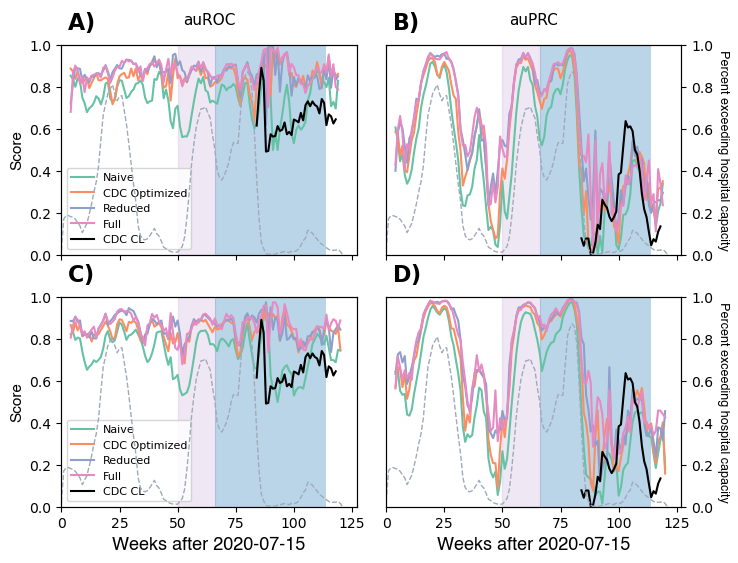

In [158]:
weeks_to_predict = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), sharex='all')
axs = axs.ravel()

# Define panel labels
panel_labels = ['A)', 'B)', 'C)', 'D)']

plot_content_titles = ["auROC", "auPRC", "", ""] 

for i, ax in enumerate(axs):

    ax.text(0.02, 1.05, r"$\mathbf{" + panel_labels[i] + "}$", transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left')


    if plot_content_titles[i]: 
        ax.set_title(plot_content_titles[i], fontsize=11, loc='center', pad=15)


    if i == 0: # Top Left: auROC
        ax.plot(range(4, 121), dt_naive_ROC, label='Naive', color=palette[0])
        ax.plot(range(4, 121), dt_CDC_ROC, label='CDC Optimized', color=palette[1])
        ax.plot(range(4, 121), dt_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(range(4, 121), dt_full_ROC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 1: # Top Right: auPRC
        ax.plot(range(4, 121), dt_naive_PRC, label='Naive', color=palette[0])
        ax.plot(range(4, 121), dt_CDC_PRC, label='CDC Optimized', color=palette[1])
        ax.plot(range(4, 121), dt_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(range(4, 121), dt_full_PRC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 2: # Bottom Left: S4_shifted ROC
        ax.plot(range(4, 121), all_current_dt_stats['Naive_performance_S4_shifted']['ROC'], label='Naive', color=palette[0])
        ax.plot(range(4, 121), all_current_dt_stats['CDC_performance_S4_shifted']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(range(4, 121), all_current_dt_stats['Reduced_performance_S4_shifted']['ROC'], label='Reduced', color=palette[2])
        ax.plot(range(4, 121), all_current_dt_stats['Full_performance_S4_shifted']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 3: # Bottom Right: S4_shifted PRC
        ax.plot(range(4, 121), all_current_dt_stats['Naive_performance_S4_shifted']['PRC'], label='Naive', color=palette[0])
        ax.plot(range(4, 121), all_current_dt_stats['CDC_performance_S4_shifted']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(range(4, 121), all_current_dt_stats['Reduced_performance_S4_shifted']['PRC'], label='Reduced', color=palette[2])
        ax.plot(range(4, 121), all_current_dt_stats['Full_performance_S4_shifted']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])


axs[0].set_ylabel('Score', **hfont, fontsize=11)
axs[2].set_ylabel('Score', **hfont, fontsize=11)

for i, ax in enumerate(axs):
    ax.set_ylim(0,1) 
    ax.grid(False)
    if i == 0 or i == 2 or i == 4: 
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(axis='y', labelsize=10)
    else: 
        ax.set_yticks([]) 
        ax.set_yticklabels([])
        ax.tick_params(axis='y', length=0) 


axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)
axs[2].set_ylim(0,1)
axs[3].set_ylim(0,1)

for i in range(0,4):
    second_axs = axs[i].twinx()
    second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    second_axs.grid(False)
    if i == 1 or i == 3 or i == 5:
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 9,  labelpad=11)
    else:
        second_axs.set_yticks([]) 
        second_axs.set_yticklabels([]) 
        second_axs.tick_params(axis='y', length=0) 

# Adding the legend
axs[0].legend(fontsize=8, ncol = 1, loc='lower left')
axs[2].legend(fontsize=8, ncol = 1, loc='lower left')

# Adding the x-axis label
axs[0].set_xlim(0, 127)
axs[1].set_xlim(0, 127)
axs[2].set_xlim(0, 127)
axs[3].set_xlim(0, 127)

axs[0].tick_params(axis='y', labelsize=10)
axs[2].tick_params(axis='y', labelsize=10)


axs[2].set_xticks([0, 25, 50, 75, 100, 125])
axs[3].set_xticks([0, 25, 50, 75, 100, 125])

axs[3].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)
axs[2].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)

# Add shaded regions (Polygons)
for ax in axs:
    # Polygon for 'delta' period
    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 1), (last_week_delta, 1), (last_week_delta, 0)],
                      alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)

    # Polygon for 'omricon' period
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 1), (last_week_omricon, 1), (last_week_omricon, 0)],
                      alpha=0.3) 
    ax.add_patch(polygon_omricon)

fig.subplots_adjust(wspace=0.1) 

plt.savefig('Figure_S4.png', dpi=300, bbox_inches='tight')
plt.show()


# S6

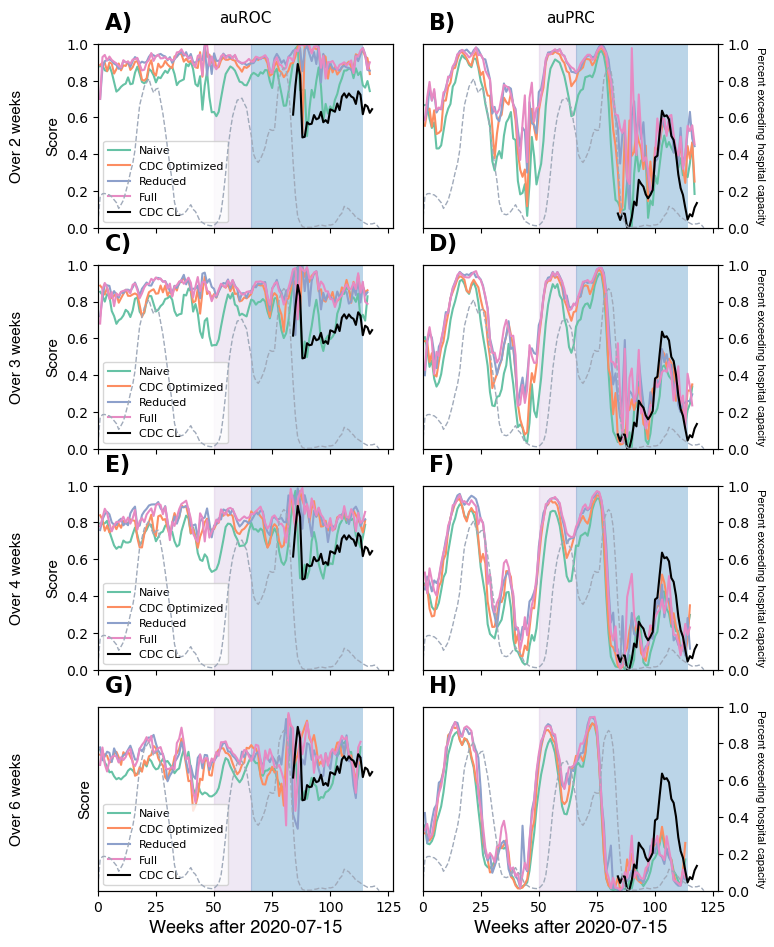

In [182]:
weeks_to_predict_3 = range(1, 123 - size_of_test_dataset - 3 - train_weeks_for_initial_model)
weeks_to_predict_2 = range(1, 123 - size_of_test_dataset - 2 - train_weeks_for_initial_model)
weeks_to_predict_4 = range(1, 123 - size_of_test_dataset - 4 - train_weeks_for_initial_model)
weeks_to_predict_6 = range(1, 123 - size_of_test_dataset - 6 - train_weeks_for_initial_model)


fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(8, 11), sharex='all')
axs = axs.ravel()


panel_labels = ['A)', 'B)', 'C)', 'D)', 'E)', 'F)', 'G)', 'H)']
plot_content_titles = ["auROC", "auPRC", "", "", "", "", "", ""]


for i, ax in enumerate(axs):
    ax.text(0.02, 1.05, r"$\mathbf{" + panel_labels[i] + "}$", transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left')

    if plot_content_titles[i]: 
        ax.set_title(plot_content_titles[i], fontsize=11, loc='center', pad=15)
   
    if i == 0: # Top-left (auROC for S6_2)
        ax.plot(weeks_to_predict_2, all_current_dt_stats['Naive_performance_S6_2']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_2, all_current_dt_stats['CDC_performance_S6_2']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_2, all_current_dt_stats['Reduced_performance_S6_2']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_2, all_current_dt_stats['Full_performance_S6_2']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 1: # Top-right (auPRC for S6_2)
        ax.plot(weeks_to_predict_2, all_current_dt_stats['Naive_performance_S6_2']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_2, all_current_dt_stats['CDC_performance_S6_2']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_2, all_current_dt_stats['Reduced_performance_S6_2']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_2, all_current_dt_stats['Full_performance_S6_2']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 2: # Second Row-left (auROC for S6_3)
        ax.plot(weeks_to_predict_3, dt_naive_ROC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_3, dt_CDC_ROC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_3, dt_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_3, dt_full_ROC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 3: # Second Row-right (auPRC for S6_3)
        ax.plot(weeks_to_predict_3, dt_naive_PRC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_3, dt_CDC_PRC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_3, dt_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_3, dt_full_PRC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 4: # Third Row-left (auROC for S6_4)
        ax.plot(weeks_to_predict_4, all_current_dt_stats['Naive_performance_S6_4']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_4, all_current_dt_stats['CDC_performance_S6_4']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_4, all_current_dt_stats['Reduced_performance_S6_4']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_4, all_current_dt_stats['Full_performance_S6_4']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 5: # Third Row-right (auPRC for S6_4)
        ax.plot(weeks_to_predict_4, all_current_dt_stats['Naive_performance_S6_4']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_4, all_current_dt_stats['CDC_performance_S6_4']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_4, all_current_dt_stats['Reduced_performance_S6_4']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_4, all_current_dt_stats['Full_performance_S6_4']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 6: # Fourth Row-left (auROC for S6_6)
        ax.plot(weeks_to_predict_6, all_current_dt_stats['Naive_performance_S6_6']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_6, all_current_dt_stats['CDC_performance_S6_6']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_6, all_current_dt_stats['Reduced_performance_S6_6']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_6, all_current_dt_stats['Full_performance_S6_6']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 7: # Fourth Row-right (auPRC for S6_6)
        ax.plot(weeks_to_predict_6, all_current_dt_stats['Naive_performance_S6_6']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_6, all_current_dt_stats['CDC_performance_S6_6']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_6, all_current_dt_stats['Reduced_performance_S6_6']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_6, all_current_dt_stats['Full_performance_S6_6']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])



# Set axis labels for left-hand side
axs[0].set_ylabel('Score', **hfont, fontsize=11)
axs[2].set_ylabel('Score', **hfont, fontsize=11)
axs[4].set_ylabel('Score', **hfont, fontsize=11)
axs[6].set_ylabel('Score', **hfont, fontsize=11)

for i, ax in enumerate(axs):
    ax.set_ylim(0,1) 
    ax.grid(False)

    if i == 0 or i == 2 or i == 4: 
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(axis='y', labelsize=10)
        ax.grid(False)
    else: 
        ax.set_yticks([]) 
        ax.set_yticklabels([])
        ax.tick_params(axis='y', length=0) 


axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)
axs[2].set_ylim(0,1)
axs[3].set_ylim(0,1)
axs[4].set_ylim(0,1)
axs[5].set_ylim(0,1)
axs[6].set_ylim(0,1)
axs[7].set_ylim(0,1)

for i in range(0,8):
    second_axs = axs[i].twinx()
    second_axs.grid(False)
    second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    if i == 1 or i == 3 or i == 5 or i == 7:
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 8,  labelpad=11)
    else:
        second_axs.set_yticks([]) 
        second_axs.set_yticklabels([]) 
        second_axs.tick_params(axis='y', length=0) 

# Adding the legend
axs[0].legend(fontsize=8, ncol = 1, loc='lower left')
axs[2].legend(fontsize=8, ncol = 1, loc='lower left')
axs[4].legend(fontsize=8, ncol = 1, loc='lower left')
axs[6].legend(fontsize=8, ncol = 1, loc='lower left')

# Adding the x-axis label
axs[0].set_xlim(0, 127)
axs[1].set_xlim(0, 127)
axs[2].set_xlim(0, 127)
axs[3].set_xlim(0, 127)
axs[4].set_xlim(0, 127)
axs[5].set_xlim(0, 127)
axs[6].set_xlim(0, 127)
axs[7].set_xlim(0, 127)



axs[6].set_xticks([0, 25, 50, 75, 100, 125])
axs[7].set_xticks([0, 25, 50, 75, 100, 125])

axs[0].tick_params(axis='y', labelsize=10)

axs[2].tick_params(axis='y', labelsize=10)

axs[4].tick_params(axis='y', labelsize=10)
axs[6].tick_params(axis='y', labelsize=10)



axs[6].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)
axs[7].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)


# Add shaded regions (Polygons)
for ax in axs:
    # Polygon for 'delta' period
    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 1), (last_week_delta, 1), (last_week_delta, 0)],
                      alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)

    # Polygon for 'omricon' period
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 1), (last_week_omricon, 1), (last_week_omricon, 0)],
                      alpha=0.3) 
    ax.add_patch(polygon_omricon)


fig.subplots_adjust(wspace=0.1) 

row_titles = ["Over 2 weeks", "Over 3 weeks", "Over 4 weeks", "Over 6 weeks"]
for i, title in enumerate(row_titles):
    ax_left = axs[i * 2]
    ax_left.text(-0.25, 0.5, title, transform=ax_left.transAxes,
                 fontsize=11, va='center', ha='right', rotation=90, **hfont)
    
# Display
plt.savefig('Figure_S6.png', dpi=300, bbox_inches='tight')
plt.show()

# S7

In [55]:
print(len(all_current_dt_stats['Full_performance_S7_4']['ROC']))
print(len(all_current_dt_stats['Full_performance_S7_10']['ROC']))
print(len(all_current_dt_stats['Full_performance_S7_26']['ROC']))

116
110
94


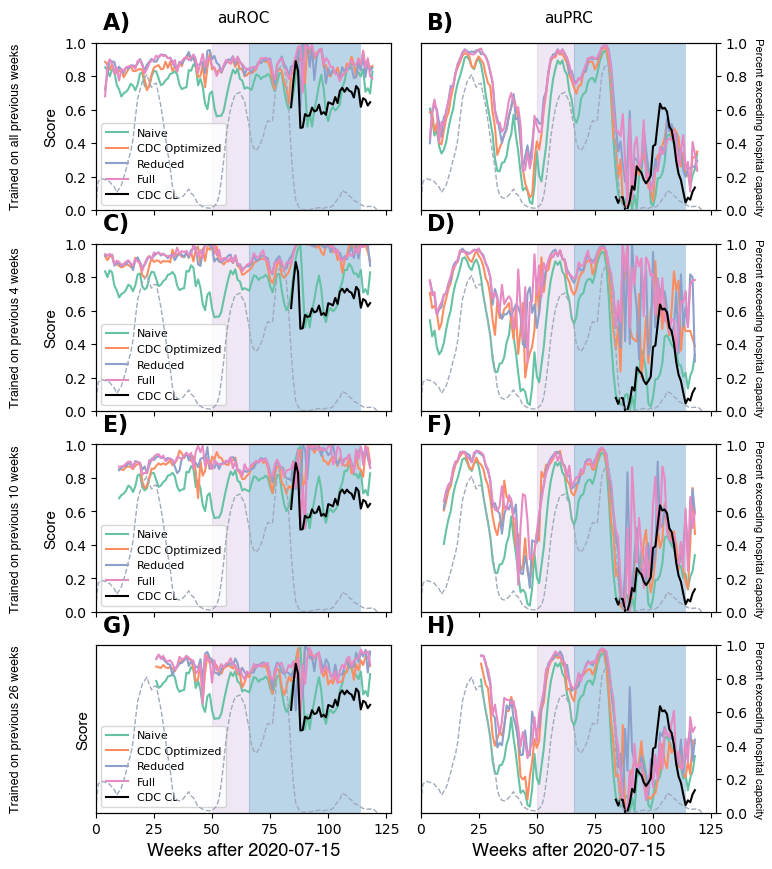

In [197]:
weeks_to_plot_S7_4 = range(4, 120)
weeks_to_plot_S7_10 = range(10, 120)
weeks_to_plot_S7_26 = range(26, 120)
weeks_to_predict_3 = range(4, 121)

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(8, 10), sharex='all')
axs = axs.ravel()

panel_labels = ['A)', 'B)', 'C)', 'D)', 'E)', 'F)', 'G)', 'H)']
plot_content_titles = ["auROC", "auPRC", "", "", "", "", "", ""]

for i, ax in enumerate(axs):
    ax.text(0.02, 1.05, r"$\mathbf{" + panel_labels[i] + "}$", transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left')

    if plot_content_titles[i]:
        ax.set_title(plot_content_titles[i], fontsize=11, loc='center', pad=15)

    if i == 0: # Top-left (dt_naive_ROC)
        ax.plot(weeks_to_predict_3, dt_naive_ROC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_3, dt_CDC_ROC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_3, dt_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_3, dt_full_ROC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 1: # Top-right (dt_naive_PRC)
        ax.plot(weeks_to_predict_3, dt_naive_PRC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict_3, dt_CDC_PRC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict_3, dt_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict_3, dt_full_PRC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 2: # Second Row-left (S7_4 ROC)
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['Naive_performance_S7_4']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['CDC_performance_S7_4']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['Reduced_performance_S7_4']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['Full_performance_S7_4']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 3: # Second Row-right (S7_4 PRC)
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['Naive_performance_S7_4']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['CDC_performance_S7_4']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['Reduced_performance_S7_4']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_plot_S7_4, all_current_dt_stats['Full_performance_S7_4']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 4: # Third Row-left (S7_10 ROC)
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['Naive_performance_S7_10']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['CDC_performance_S7_10']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['Reduced_performance_S7_10']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['Full_performance_S7_10']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 5: # Third Row-right (S7_10 PRC)
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['Naive_performance_S7_10']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['CDC_performance_S7_10']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['Reduced_performance_S7_10']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_plot_S7_10, all_current_dt_stats['Full_performance_S7_10']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 6: # Fourth Row-left (S7_26 ROC)
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['Naive_performance_S7_26']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['CDC_performance_S7_26']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['Reduced_performance_S7_26']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['Full_performance_S7_26']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 7: # Fourth Row-right (S7_26 PRC)
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['Naive_performance_S7_26']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['CDC_performance_S7_26']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['Reduced_performance_S7_26']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_plot_S7_26, all_current_dt_stats['Full_performance_S7_26']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])

axs[0].set_ylabel('Score', **hfont, fontsize=11)
axs[2].set_ylabel('Score', **hfont, fontsize=11)
axs[4].set_ylabel('Score', **hfont, fontsize=11)
axs[6].set_ylabel('Score', **hfont, fontsize=11)

for i, ax in enumerate(axs):
    ax.set_ylim(0,1)
    ax.grid(False)

    if i == 0 or i == 2 or i == 4: 
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(axis='y', labelsize=10)
        ax.grid(False)
    else:
        ax.set_yticks([]) 
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 


axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)
axs[2].set_ylim(0,1)
axs[3].set_ylim(0,1)
axs[4].set_ylim(0,1)
axs[5].set_ylim(0,1)
axs[6].set_ylim(0,1)
axs[7].set_ylim(0,1)

for i in range(0,8):
    second_axs = axs[i].twinx()
    second_axs.grid(False)
    second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    if i == 1 or i == 3 or i == 5 or i == 7:
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 8,  labelpad=11)
    else:
        second_axs.set_yticks([]) 
        second_axs.set_yticklabels([]) 
        second_axs.tick_params(axis='y', length=0) 

# Adding the legend
axs[0].legend(fontsize=8, ncol = 1, loc='lower left')
axs[2].legend(fontsize=8, ncol = 1, loc='lower left')
axs[4].legend(fontsize=8, ncol = 1, loc='lower left')
axs[6].legend(fontsize=8, ncol = 1, loc='lower left')

# Adding the x-axis label
axs[0].set_xlim(0, 127)
axs[1].set_xlim(0, 127)
axs[2].set_xlim(0, 127)
axs[3].set_xlim(0, 127)
axs[4].set_xlim(0, 127)
axs[5].set_xlim(0, 127)
axs[6].set_xlim(0, 127)
axs[7].set_xlim(0, 127)



axs[6].set_xticks([0, 25, 50, 75, 100, 125])
axs[7].set_xticks([0, 25, 50, 75, 100, 125])

axs[0].tick_params(axis='y', labelsize=10)

axs[2].tick_params(axis='y', labelsize=10)

axs[4].tick_params(axis='y', labelsize=10)
axs[6].tick_params(axis='y', labelsize=10)



axs[6].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)
axs[7].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)


# Add shaded regions (Polygons)
for ax in axs:
    # Polygon for 'delta' period
    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 1), (last_week_delta, 1), (last_week_delta, 0)],
                      alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)

    # Polygon for 'omricon' period
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 1), (last_week_omricon, 1), (last_week_omricon, 0)],
                      alpha=0.3) 
    ax.add_patch(polygon_omricon)

row_titles = ["Trained on all previous weeks", "Trained on previous 4 weeks", "Trained on previous 10 weeks", "Trained on previous 26 weeks"]
for i, title in enumerate(row_titles):
    ax_left = axs[i * 2]
    ax_left.text(-0.25, 0.5, title, transform=ax_left.transAxes,
                 fontsize=9, va='center', ha='right', rotation=90, **hfont)

fig.subplots_adjust(wspace=0.1) 

# Display
plt.savefig('Figure_S7.png', dpi=300, bbox_inches='tight')
plt.show()

# S8

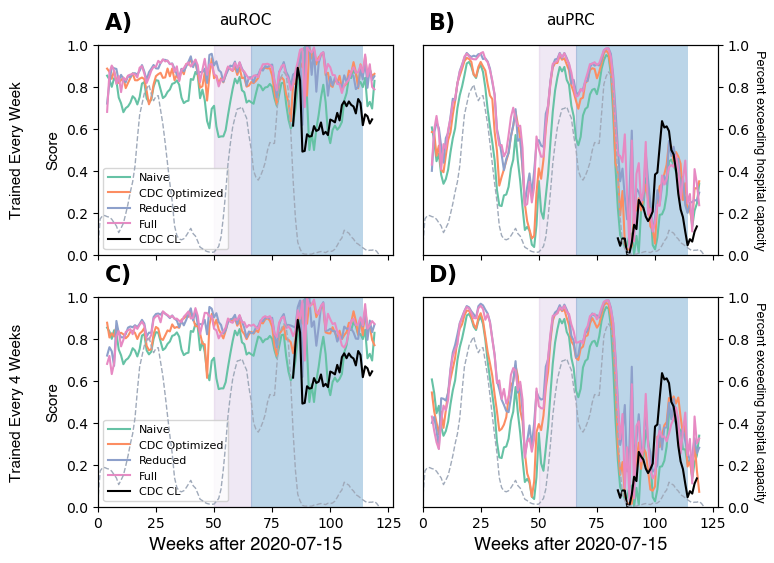

In [185]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), sharex='all')
axs = axs.ravel()

panel_labels = ['A)', 'B)', 'C)', 'D)']
plot_content_titles = ["auROC", "auPRC", "", ""]

for i, ax in enumerate(axs):
    ax.text(0.02, 1.05, r"$\mathbf{" + panel_labels[i] + "}$", transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left')

    if plot_content_titles[i]: 
        ax.set_title(plot_content_titles[i], fontsize=11, loc='center', pad=15)

    if i == 0: # Top-left (auROC)
        ax.plot(weeks_to_predict, dt_naive_ROC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, dt_CDC_ROC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, dt_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, dt_full_ROC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 1: # Top-right (auPRC)
        ax.plot(weeks_to_predict, dt_naive_PRC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, dt_CDC_PRC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, dt_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, dt_full_PRC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 2: # Bottom-left (S8 ROC)
        ax.plot(weeks_to_predict, all_current_dt_stats['Naive_performance_S8']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, all_current_dt_stats['CDC_performance_S8']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, all_current_dt_stats['Reduced_performance_S8']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, all_current_dt_stats['Full_performance_S8']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 3: # Bottom-right (S8 PRC)
        ax.plot(weeks_to_predict, all_current_dt_stats['Naive_performance_S8']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, all_current_dt_stats['CDC_performance_S8']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, all_current_dt_stats['Reduced_performance_S8']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, all_current_dt_stats['Full_performance_S8']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])

axs[0].set_ylabel('Score', **hfont, fontsize=11)
axs[2].set_ylabel('Score', **hfont, fontsize=11)

for i, ax in enumerate(axs):
    ax.set_ylim(0,1)
    ax.grid(False)
    if i == 0 or i == 2 or i == 4: 
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(axis='y', labelsize=10)
    else: 
        ax.set_yticks([]) 
        ax.set_yticklabels([])
        ax.tick_params(axis='y', length=0) 


axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)
axs[2].set_ylim(0,1)
axs[3].set_ylim(0,1)

for i in range(0,4):
    second_axs = axs[i].twinx()
    second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    second_axs.grid(False)
    if i == 1 or i == 3 or i == 5:
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 9,  labelpad=11)
    else:
        second_axs.set_yticks([]) 
        second_axs.set_yticklabels([]) 
        second_axs.tick_params(axis='y', length=0) 

# Adding the legend
axs[0].legend(fontsize=8, ncol = 1, loc='lower left')
axs[2].legend(fontsize=8, ncol = 1, loc='lower left')

# Adding the x-axis label
axs[0].set_xlim(0, 127)
axs[1].set_xlim(0, 127)
axs[2].set_xlim(0, 127)
axs[3].set_xlim(0, 127)

axs[2].set_xticks([0, 25, 50, 75, 100, 125])
axs[3].set_xticks([0, 25, 50, 75, 100, 125])

axs[0].tick_params(axis='y', labelsize=10)
axs[2].tick_params(axis='y', labelsize=10)

axs[3].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)
axs[2].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)

# Add shaded regions (Polygons)
for ax in axs:
    # Polygon for 'delta' period
    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 1), (last_week_delta, 1), (last_week_delta, 0)],
                      alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)

    # Polygon for 'omricon' period
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 1), (last_week_omricon, 1), (last_week_omricon, 0)],
                      alpha=0.3) 
    ax.add_patch(polygon_omricon)
    
row_titles = ["Trained Every Week", "Trained Every 4 Weeks"]
for i, title in enumerate(row_titles):
    ax_left = axs[i * 2]
    ax_left.text(-0.25, 0.5, title, transform=ax_left.transAxes,
                 fontsize=11, va='center', ha='right', rotation=90, **hfont)

fig.subplots_adjust(wspace=0.1) 

# Display
plt.savefig('Figure_S8.png', dpi=300, bbox_inches='tight')
plt.show()

# S5

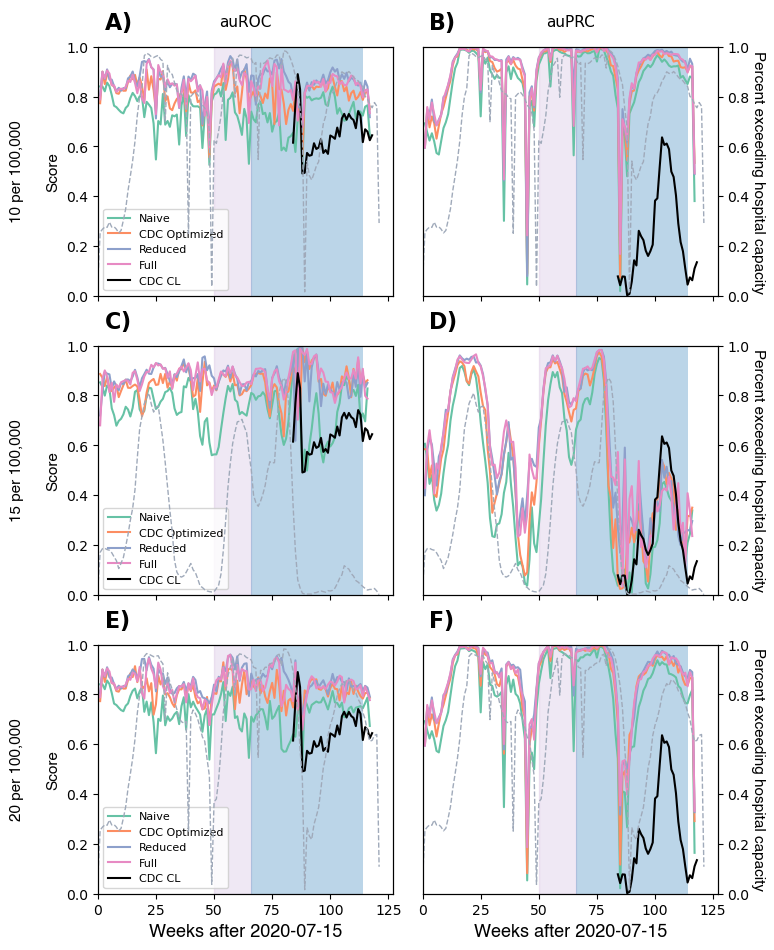

In [110]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 11), sharex='all')
axs = axs.ravel()

panel_labels = ['A)', 'B)', 'C)', 'D)', 'E)', 'F)']
plot_content_titles = ["auROC", "auPRC", "", "", "", ""]

for i, ax in enumerate(axs):
    ax.text(0.02, 1.05, r"$\mathbf{" + panel_labels[i] + "}$", transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left')

    if plot_content_titles[i]:
        ax.set_title(plot_content_titles[i], fontsize=11, loc='center', pad=15)

    if i == 0: # Top-left (10 per 100k - ROC)
        ax.plot(weeks_to_predict, all_current_dt_stats['Naive_10_performance_S5']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, all_current_dt_stats['CDC_10_performance_S5']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, all_current_dt_stats['Reduced_10_performance_S5']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, all_current_dt_stats['Full_10_performance_S5']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 1: # Top-right (10 per 100k - PRC)
        ax.plot(weeks_to_predict, all_current_dt_stats['Naive_10_performance_S5']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, all_current_dt_stats['CDC_10_performance_S5']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, all_current_dt_stats['Reduced_10_performance_S5']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, all_current_dt_stats['Full_10_performance_S5']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 2: # Middle-left (15 per 100k - ROC) 
        ax.plot(weeks_to_predict, dt_naive_ROC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, dt_CDC_ROC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, dt_reduced_ROC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, dt_full_ROC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 3: # Middle-right (15 per 100k - PRC) 
        ax.plot(weeks_to_predict, dt_naive_PRC, label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, dt_CDC_PRC, label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, dt_reduced_PRC, label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, dt_full_PRC, label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])
    elif i == 4: # Bottom-left (20 per 100k - ROC)
        ax.plot(weeks_to_predict, all_current_dt_stats['Naive_20_performance_S5']['ROC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, all_current_dt_stats['CDC_20_performance_S5']['ROC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, all_current_dt_stats['Reduced_20_performance_S5']['ROC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, all_current_dt_stats['Full_20_performance_S5']['ROC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['ROC'], label='CDC CL', color=palette[4])
    elif i == 5: # Bottom-right (20 per 100k - PRC)
        ax.plot(weeks_to_predict, all_current_dt_stats['Naive_20_performance_S5']['PRC'], label='Naive', color=palette[0])
        ax.plot(weeks_to_predict, all_current_dt_stats['CDC_20_performance_S5']['PRC'], label='CDC Optimized', color=palette[1])
        ax.plot(weeks_to_predict, all_current_dt_stats['Reduced_20_performance_S5']['PRC'], label='Reduced', color=palette[2])
        ax.plot(weeks_to_predict, all_current_dt_stats['Full_20_performance_S5']['PRC'], label='Full', color=palette[3])
        ax.plot(range(84, 119), CL_metrics['PRC'], label='CDC CL', color=palette[4])


# Set axis labels for left-hand side
axs[0].set_ylabel('Score', **hfont, fontsize=11)
axs[2].set_ylabel('Score', **hfont, fontsize=11)
axs[4].set_ylabel('Score', **hfont, fontsize=11)

for i, ax in enumerate(axs):
    ax.set_ylim(0,1)
    ax.grid(False)
    if i == 0 or i == 2 or i == 4: 
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(axis='y', labelsize=10)
    else: 
        ax.set_yticks([]) 
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 


axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)
axs[2].set_ylim(0,1)
axs[3].set_ylim(0,1)
axs[4].set_ylim(0,1)
axs[5].set_ylim(0,1)

for i in range(0,6):
    second_axs = axs[i].twinx()
    second_axs.grid(False)
    if i == 0 or i == 1:
        second_axs.plot(range(0, len(percent_exceed_capacity_10)), percent_exceed_capacity_10, linewidth = 1, color = '#A0AABA', linestyle = '--')
    elif i == 2 or i==3:
        second_axs.plot(range(0, len(percent_exceed_capacity)), percent_exceed_capacity, linewidth = 1, color = '#A0AABA', linestyle = '--')
    else:
        second_axs.plot(range(0, len(percent_exceed_capacity_20)), percent_exceed_capacity_20, linewidth = 1, color = '#A0AABA', linestyle = '--')
    second_axs.set_ylim(0,1)
    if i == 1 or i == 3 or i == 5:
        second_axs.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        second_axs.set_ylabel('Percent exceeding hospital capacity',**hfont, rotation=-90, fontsize = 11,  labelpad=11)
    else:
        second_axs.set_yticks([]) 
        second_axs.set_yticklabels([]) 
        second_axs.tick_params(axis='y', length=0) 

# Adding the legend
axs[0].legend(fontsize=8, ncol = 1, loc='lower left')
axs[2].legend(fontsize=8, ncol = 1, loc='lower left')
axs[4].legend(fontsize=8, ncol = 1, loc='lower left')

# Adding the x-axis label
axs[0].set_xlim(0, 127)
axs[1].set_xlim(0, 127)
axs[2].set_xlim(0, 127)
axs[3].set_xlim(0, 127)
axs[4].set_xlim(0, 127)
axs[5].set_xlim(0, 127)


axs[4].set_xticks([0, 25, 50, 75, 100, 125])
axs[5].set_xticks([0, 25, 50, 75, 100, 125])

axs[0].tick_params(axis='y', labelsize=10)

axs[2].tick_params(axis='y', labelsize=10)

axs[4].tick_params(axis='y', labelsize=10)



axs[4].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)
axs[5].set_xlabel('Weeks after 2020-07-15',**hfont,  fontsize = 13)



# Adding Subtitles
row_titles = ["10 per 100,000", "15 per 100,000", "20 per 100,000"]
for i, title in enumerate(row_titles):
    # i*2 gives the index of the first subplot in each row (0, 2, 4)
    ax_left = axs[i * 2]
    ax_left.text(-0.25, 0.5, title, transform=ax_left.transAxes,
                 fontsize=11, va='center', ha='right', rotation=90, **hfont)

# Add shaded regions (Polygons)
for ax in axs:
    # Polygon for 'delta' period
    polygon_delta = Polygon([(first_week_delta, 0), (first_week_delta, 1), (last_week_delta, 1), (last_week_delta, 0)],
                      alpha=0.3, color='#cdb4db')
    ax.add_patch(polygon_delta)
    

    # Polygon for 'omricon' period
    polygon_omricon = Polygon([(first_week_omricon, 0), (first_week_omricon, 1), (last_week_omricon, 1), (last_week_omricon, 0)],
                      alpha=0.3) 
    ax.add_patch(polygon_omricon)

fig.subplots_adjust(wspace=0.1) 

plt.savefig('Figure_S5.png', dpi=300, bbox_inches='tight')
plt.show()